In [18]:
import jax
import equinox as eqx
import jax.random as jnr
import numpy as np
import jax.numpy as jnp
import optax
import torch
import torchvision
from jaxtyping import Array, Float, Int, PyTree
import matplotlib.pyplot as plt

## Hyperparameters

In [32]:
BATCH_SIZE = 64
LEARNING_RATE = 1e-03
STEPS = 100
PRINT_EVERY = 10
SEED = 5678

key = jnr.PRNGKey(SEED)

## Dataset - Dataloader(from PyTorch)

In [33]:
normalise_data = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = torchvision.datasets.MNIST(
    "MNIST",
    train=True,
    download=True,
    transform=normalise_data,
)
test_dataset = torchvision.datasets.MNIST(
    "MNIST",
    train=False,
    download=True,
    transform=normalise_data,
)
trainloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True
)


Shape of Trainloader, Input(x):  (64, 1, 28, 28)
Shape of Trainloader, Output(y):  (64,)
3


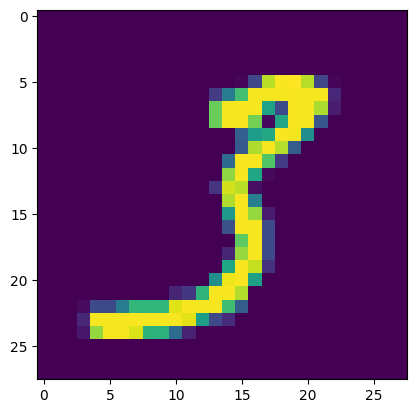

In [34]:
dummy_x, dummy_y = next(iter(trainloader))
dummy_x = dummy_x.numpy()
dummy_y = dummy_y.numpy()

print("Shape of Trainloader, Input(x): ", dummy_x.shape)
print("Shape of Trainloader, Output(y): ", dummy_y.shape)

plt.imshow(dummy_x[1][0][:][:])
print(dummy_y[1])
plt.show()

# Explaining CNN dimensions
$
\begin{array}{l}
\text{Dimension of the Linear Dense Layer after Convolution and Pooling:} \\
\\
\text{Definitions:} \\
\quad O: \text{Output Dimension (Height/Width)}, \quad I: \text{Input Dimension}, \\
\quad S: \text{Stride}, \quad P: \text{Padding}, \quad K: \text{Kernel Size} \\
\\
\text{Example Layers:} \\
\quad \text{Conv2d}(\text{in}=1, \text{out}=10, K=3), \quad \text{MaxPool2d}(K_p=2) \\
\\
\text{Parameters Used (from your original calculation):} \\
\quad I = 28 \quad \text{(Input Image Size)} \\
\quad K_{\text{conv}} = 3 \quad \text{(Conv Kernel Size)} \\
\quad S_{\text{conv}} = 1 \quad \text{(Conv Stride, by default)} \\
\quad P_{\text{conv}} = 0 \quad \text{(Conv Padding, by default)} \\
\quad K_{\text{pool}} = 2 \quad \text{(Pool Kernel Size)} \\
\quad S_{\text{pool}} = 1 \quad \text{(Pool Stride, as used in your calculation)} \\
\\
\text{1. Output Dimension after Convolution } (O_{\text{conv}}): \\
\quad O_{\text{conv}} = \frac{I - K_{\text{conv}} + 2P_{\text{conv}}}{S_{\text{conv}}} + 1 \\
\quad O_{\text{conv}} = \frac{28 - 3 + 2(0)}{1} + 1 = \frac{25}{1} + 1 = 26 \\
\quad \text{Convolution Output Shape} = [10, 26, 26] \\
\\
\text{2. Output Dimension after Max Pooling } (O_{\text{pool}}): \\
\quad O_{\text{pool}} = \frac{O_{\text{conv}} - K_{\text{pool}} + 2P_{\text{pool}}}{S_{\text{pool}}} + 1 \\
\quad O_{\text{pool}} = \frac{26 - 2 + 2(0)}{1} + 1 = \frac{24}{1} + 1 = 25 \\
\quad \text{Pooling Output Shape} = [10, 25, 25] \\
\\
\text{3. Total Dimension for the Linear Dense Layer (Flattened):} \\
\quad \text{Total Dimension} = 10 \times 25 \times 25 = 6250 \\
\end{array}
$

In [74]:
class CNN(eqx.Module):
    layers: list

    def __init__(self, key):
        key1, key2, key3, key4, key5 = jnr.split(key, 5)
        
        self.layers = [
            eqx.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride = 1, key=key1),
            eqx.nn.MaxPool2d(kernel_size=2, stride = 2),
            jax.nn.relu,
            eqx.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=2, stride=2, key=key2),
            eqx.nn.MaxPool2d(kernel_size=2, stride=2),
            jax.nn.relu,
            jnp.ravel,
            eqx.nn.Linear(576, 128, key=key3),
            # jax.nn.relu,
            # eqx.nn.Linear(256, 128, key=key3),
            jax.nn.relu,
            # eqx.nn.Linear(128, 64, key=key5),
            # jax.nn.relu,
            eqx.nn.Linear(128, 10, key=key4),
            jax.nn.softmax,
        ]

    def __call__(self, x: Float[Array, "1 28 28"]):

        for layer in self.layers:
            x = layer(x)
        return x
        

In [75]:
key, subkey = jnr.split(key, 2)
model = CNN(subkey)


In [76]:
print(model)

CNN(
  layers=[
    Conv2d(
      num_spatial_dims=2,
      weight=f32[32,1,3,3],
      bias=f32[32,1,1],
      in_channels=1,
      out_channels=32,
      kernel_size=(3, 3),
      stride=(1, 1),
      padding=((0, 0), (0, 0)),
      dilation=(1, 1),
      groups=1,
      use_bias=True,
      padding_mode='ZEROS'
    ),
    MaxPool2d(
      init=-inf,
      operation=<function max>,
      num_spatial_dims=2,
      kernel_size=(2, 2),
      stride=(2, 2),
      padding=((0, 0), (0, 0)),
      use_ceil=False
    ),
    <PjitFunction of <function relu at 0x00000168E405E3B0>>,
    Conv2d(
      num_spatial_dims=2,
      weight=f32[64,32,2,2],
      bias=f32[64,1,1],
      in_channels=32,
      out_channels=64,
      kernel_size=(2, 2),
      stride=(2, 2),
      padding=((0, 0), (0, 0)),
      dilation=(1, 1),
      groups=1,
      use_bias=True,
      padding_mode='ZEROS'
    ),
    MaxPool2d(
      init=-inf,
      operation=<function max>,
      num_spatial_dims=2,
      kernel_size=(2

In [77]:
def cross_entropy(
    y: Int[Array, " batch"], pred_y: Float[Array, "batch 10"] # pred_y are probabilities (after softmax)
) -> Float[Array, ""]:

    # Select the predicted probability for the true class
    pred_y_for_true_class = jnp.take_along_axis(pred_y, jnp.expand_dims(y, 1), axis=1)
    
    # Calculate the negative log likelihood
    # Note: jnp.log is safe as pred_y are probabilities > 0
    return -jnp.mean(jnp.log(pred_y_for_true_class))

def loss_fn(
    model: CNN, x: Float[Array, "batch 1 28 28"], y: Int[Array, "batch"]
) -> Float[Array, ""]:
    y_pred = jax.vmap(model)(x)

    return cross_entropy(y, y_pred)


In [78]:
@ eqx.filter_jit
def compute_accuracy(
    model: CNN, x: Float[Array, "batch 1 28 28"], y: Int[Array, "batch"]
) -> Float[Array, ""]:

    y_pred = jax.vmap(model)(x)
    y_pred = jnp.argmax(y_pred, axis=1)
    res = jnp.mean(y == y_pred)
    return res

def evaluate(model: CNN, testloader: torch.utils.data.DataLoader):
    """This function evaluates the model on the test dataset,
    computing both the average loss and the average accuracy.
    """
    avg_loss = 0
    avg_acc = 0
    for x, y in testloader:
        x = x.numpy()
        y = y.numpy()
        # Note that all the JAX operations happen inside `loss` and `compute_accuracy`,
        # and both have JIT wrappers, so this is fast.
        avg_loss += loss_fn(model, x, y)
        avg_acc += compute_accuracy(model, x, y)
    return avg_loss / len(testloader), avg_acc / len(testloader) 

In [79]:
def train(
    model: CNN, testloader: torch.utils.data.DataLoader, trainloader: torch.utils.data.DataLoader,
    optim: optax.GradientTransformation,
    steps: int,
    print_every: int
) -> CNN:

    opt_state = optim.init(eqx.filter(model, eqx.is_array))
    # hist_loss = []
    
    @eqx.filter_jit
    def make_step(
        model: CNN,
        opt_state: PyTree,
        x: Float[Array, "batch 1 28 28"],
        y: Float[Array, "batch"],
        dummy_arg: int = 0  # <--- Added this dummy argument
    ):

        loss_val, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)
        updates, opt_state =optim.update(
            grads, opt_state, eqx.filter(model, eqx.is_array)
        )
        model = eqx.apply_updates(model, updates)

        return model, opt_state, loss_val

    def infinite_trainloader():
        while True:
            yield from trainloader
    
    for step, (x,y) in zip(range(steps), infinite_trainloader()):

        x = x.numpy()
        y = y.numpy()

        model, opt_state, train_loss = make_step(model, opt_state, x, y)
        hist_loss.append(train_loss.item())

        if (step % print_every == 0) or (step == steps-1):
            test_loss, test_accuracy = evaluate(model, testloader)
            print(f"step ={step}, train_loss= {train_loss.item()}, ")
            print(f"test_loss={test_loss.item()}, test_accuracy={test_accuracy.item()}")

    plt.show()
    return model                       
    

In [80]:
optim = optax.adamw(LEARNING_RATE)
hist_loss = []
model = train(model, trainloader, testloader, optim, STEPS, PRINT_EVERY)


step =0, train_loss= 2.298806667327881, 
test_loss=2.2957286834716797, test_accuracy=0.09271721541881561
step =10, train_loss= 2.1544899940490723, 
test_loss=2.1403775215148926, test_accuracy=0.4535747468471527
step =20, train_loss= 1.8059837818145752, 
test_loss=1.7528767585754395, test_accuracy=0.5593683123588562
step =30, train_loss= 1.223531723022461, 
test_loss=1.2576221227645874, test_accuracy=0.6722581386566162
step =40, train_loss= 1.0113905668258667, 
test_loss=0.965417742729187, test_accuracy=0.7020422220230103


KeyboardInterrupt: 

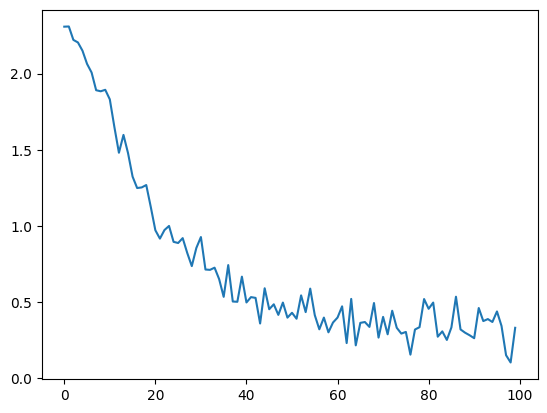

In [98]:
plt.plot(hist_loss)

In [53]:
inf_x, inf_y = next(iter(testloader))

Shape of Trainloader, Input(x):  (64, 1, 28, 28)
Shape of Trainloader, Output(y):  (64,)
5


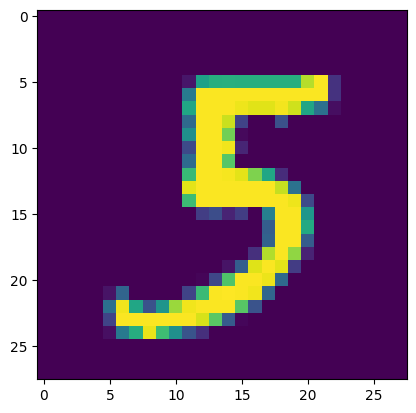

In [54]:
inf_x = inf_x.numpy()
inf_y = inf_y.numpy()

print("Shape of Trainloader, Input(x): ", inf_x.shape)
print("Shape of Trainloader, Output(y): ", inf_y.shape)

plt.imshow(inf_x[1][0][:][:])
print(inf_y[1])
plt.show()

In [57]:
jax.vmap(model)(inf_x)

Array([[1.74940377e-03, 1.03131439e-04, 2.92810542e-03, 8.23674202e-01,
        7.81480630e-05, 2.12363026e-04, 2.01418618e-04, 3.38172540e-05,
        1.69738129e-01, 1.28123094e-03],
       [7.56133086e-05, 6.99756492e-05, 2.58410164e-05, 9.98793840e-01,
        8.05908769e-07, 1.22001002e-05, 1.44902151e-05, 1.66666723e-05,
        9.23322805e-04, 6.71613088e-05],
       [9.09208844e-04, 9.96696690e-05, 1.99283939e-04, 2.58993311e-03,
        1.04091456e-02, 3.58670193e-04, 2.29562371e-04, 2.10699439e-01,
        8.48992262e-03, 7.66015232e-01],
       [2.21936316e-05, 9.98314142e-01, 3.64230247e-04, 9.12342293e-05,
        5.70848613e-07, 3.16330102e-07, 5.80103697e-05, 8.19603680e-04,
        3.14466597e-04, 1.52580860e-05],
       [2.71637662e-04, 4.28558378e-05, 3.76585049e-05, 1.79251030e-04,
        4.19085443e-01, 3.29931529e-04, 2.31146137e-03, 6.43855473e-03,
        2.62841233e-03, 5.68674803e-01],
       [4.59908741e-03, 4.26875995e-05, 6.59389095e-03, 3.93590526e-05,
   